# Note: Refresh notebook after updating the parameters in inputs.

In [1]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
import pickle # for saving simulations

%matplotlib widget

In [2]:
parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
spme = pybamm.lithium_ion.SPMe()

c_rate_d = "C/3"
c_rate_c = "C/3"


experiment = pybamm.Experiment(
    [
        ("Discharge at "+c_rate_d+" until 3V",
        "Rest for 10 sec",
        "Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/20")
    ] ,
    # ] *40,
    termination="50% capacity",
#     cccv_handling="ode",
)

sim_0 = pybamm.Simulation(spme, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol_0 = sim_0.solve(initial_soc=1)

t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
Q = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries

CasADi - 2023-09-26 09:47:46 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:515]


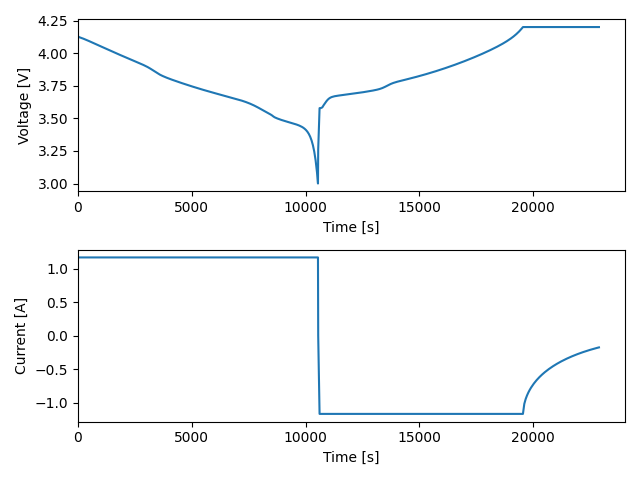

In [3]:
fig,ax = plt.subplots(2,1)
ax1 = ax.flat[0]
ax1.plot(t,Vt)
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t,I)
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
fig.tight_layout()

In [4]:
c_rate_d = "C/20"
c_rate_c = "C/20"


experiment = pybamm.Experiment(
    [
        ("Discharge at "+c_rate_d+" until 3V",
        "Rest for 1 hr",
        "Charge at "+c_rate_c+" until 4.2V")
    ] ,
    # ] *40,
    termination="50% capacity",
#     cccv_handling="ode",
)

sim_1 = pybamm.Simulation(spme, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol_1 = sim_1.solve(initial_soc=1)

t = sol_1["Time [s]"].entries
I = sol_1["Current [A]"].entries
Q = sol_1['Discharge capacity [A.h]'].entries
Vt = sol_1["Terminal voltage [V]"].entries

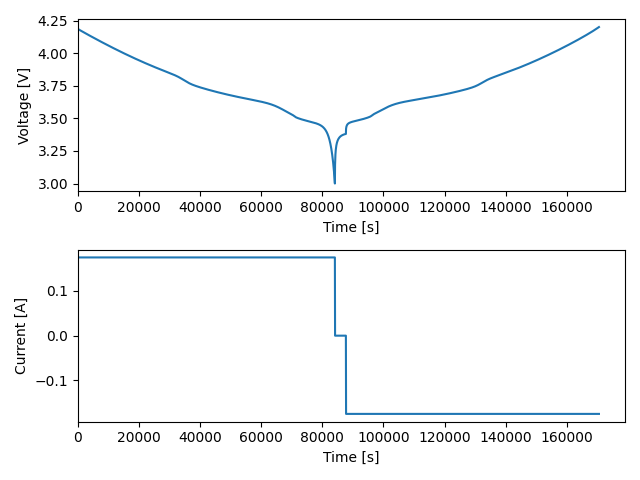

In [5]:
fig,ax = plt.subplots(2,1)
ax1 = ax.flat[0]
ax1.plot(t,Vt)
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t,I)
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
fig.tight_layout()

# Alternatively, you can update parameters in the script, on the fly, instead of updating in the inputs folder. But this change will be valid only in this script.

In [72]:
from pybamm import exp, constants


def electrolyte_conductivity_Siegel2022(c_e, T):
    C = c_e/1000.0
    k_Kmax = 3.58e-7
    k_Cmax = 4.84e-6
    k_a = 0.4793
    k_P2 = -0.3299
    k_P1 = 2.22e-14
    k_Ea = 13490
    k_Rg = 8.314
    k_T0 = 162.5

    Ke = 100*k_Kmax*((C/k_Cmax)**k_a)*exp(k_P2*((C-k_Cmax)**2)-k_P1*((C-k_Cmax)/k_Cmax))*exp((-k_Ea/k_Rg)*(1/T-1/k_T0))

    return Ke


def electrolyte_diffusivity_Siegel(c_e, T):
    C = c_e/1000.0
    D00 = -487.2
    D01 = -28530000
    Tg0 = 58320
    Tg1 = 50.31
    D10 = -52.79
    D11 = -3061000
    
    De = (1e-14)*10**((D00+D01/(T-((Tg0+C*Tg1))))+(D10+D11/(T-((Tg0+C*Tg1))))*C)

    return De


In [7]:
parameter_values.search("electrolyte")

EC initial concentration in electrolyte [mol.m-3]	4541.0
Electrolyte conductivity [S.m-1]	<function electrolyte_conductivity_Siegel at 0x00000214FCEBA940>
Electrolyte diffusivity [m2.s-1]	<function electrolyte_diffusivity_Siegel at 0x00000214FCEBA9D0>
Initial concentration in electrolyte [mol.m-3]	1000.0
Negative electrode Bruggeman coefficient (electrolyte)	1.5
Positive electrode Bruggeman coefficient (electrolyte)	1.5
Separator Bruggeman coefficient (electrolyte)	1.5
Typical electrolyte concentration [mol.m-3]	1000.0


In [73]:
parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)

c_rate_d = "C/3"
c_rate_c = "C/3"

parameter_values.update(
    {
        "Negative electrode conductivity [S.m-1]": 100,
        "Maximum concentration in negative electrode [mol.m-3]": 28746,
        "Negative electrode diffusion coefficient [m2.s-1]": 5.0E-15,
        "Electrolyte conductivity [S.m-1]": electrolyte_conductivity_Siegel2022,
        "Electrolyte diffusivity [m2.s-1]":electrolyte_diffusivity_Siegel,
    },
    check_already_exists=False,
)

experiment = pybamm.Experiment(
    [
        ("Discharge at "+c_rate_d+" until 3V",
        "Rest for 10 sec",
        "Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/20")
    ] ,
    # ] *40,
    termination="50% capacity",
#     cccv_handling="ode",
)

sim_0 = pybamm.Simulation(spme, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol_0 = sim_0.solve(initial_soc=1)

t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
Q = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries

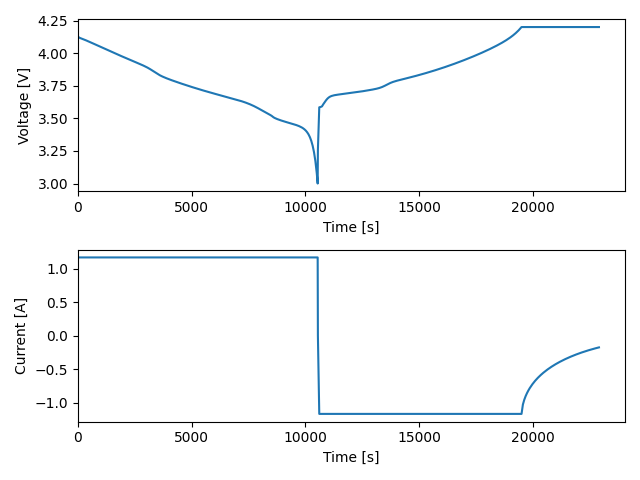

In [74]:
fig,ax = plt.subplots(2,1)
ax1 = ax.flat[0]
ax1.plot(t,Vt)
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t,I)
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
fig.tight_layout()